In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os
import time
import sys
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import validation_curve
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn import tree #决策树算法

# 1 数据处理

In [2]:
data = pd.read_csv("D:\\PycharmProjects\\python_finalwork\\UserBehavior.csv")
data.columns = ["userid", 'itemid', 'categoryid', 'type', 'timestamp']
data.head()

,userid,itemid,categoryid,type,timestamp
0,1,2333346,2520771,pv,1511561733
1,1,2576651,149192,pv,1511572885
2,1,3830808,4181361,pv,1511593493
3,1,4365585,2520377,pv,1511596146
4,1,4606018,2735466,pv,1511616481


## 1.1 缺失值和重复值处理

In [3]:
# 查看数据缺失值，无缺失值
missing_values = data.isnull().sum()

In [4]:
# 查看重复个数，只有49条
duplicate_count = data.duplicated().sum()
duplicate_count
# 去除重复记录
data = data.drop_duplicates()

In [5]:
# 查看数据类型
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100150757 entries, 0 to 100150805
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   userid      int64 
 1   itemid      int64 
 2   categoryid  int64 
 3   type        object
 4   timestamp   int64 
dtypes: int64(4), object(1)
memory usage: 4.5+ GB


## 1.2  时间特征处理

In [9]:
# 时间戳转换单位，同时提取日期、时间、小时
# 1.矢量化转换 
# errors='coerce'：如果遇到非法时间戳，会将其设为 NaT (空时间)，而不是报错崩溃
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s', errors='coerce')

# 2. 清洗：删除转换失败的非法行
data = data.dropna(subset=['timestamp'])

# 3. 提取日期、时间、小时 (直接利用 .dt 属性，无需 split 字符串)
data['Date'] = data['timestamp'].dt.date
data['Time'] = data['timestamp'].dt.time
data['Hour'] = data['timestamp'].dt.hour

# 只取2017年11月25日至2017年12月3日之间的数据进行研究
data = data[(data["timestamp"] >= '2017-11-25') & (data["timestamp"] < '2017-12-04')]
# 检查过滤后的结果
print(data['Date'].value_counts().sort_index())
data.head()

2017-11-25    10511597
2017-11-26    10571039
2017-11-27    10013455
2017-11-28     9884185
2017-11-29    10319060
2017-11-30    10541695
2017-12-01    11171505
2017-12-02    13940942
2017-12-03    11961006
Name: Date, dtype: int64


,userid,itemid,categoryid,type,timestamp,Date,Time,Hour
1,1,2576651,149192,pv,2017-11-25 01:21:25,2017-11-25,01:21:25,1
2,1,3830808,4181361,pv,2017-11-25 07:04:53,2017-11-25,07:04:53,7
3,1,4365585,2520377,pv,2017-11-25 07:49:06,2017-11-25,07:49:06,7
4,1,4606018,2735466,pv,2017-11-25 13:28:01,2017-11-25,13:28:01,13
5,1,230380,411153,pv,2017-11-25 21:22:22,2017-11-25,21:22:22,21


## 1.3 构造天级中间表

In [10]:
daily_user = ( # 按usserid和日期聚合
    data.groupby(['userid', 'Date'])
      .agg(
          pv_cnt   = ('type', lambda x: (x == 'pv').sum()), #浏览
          cart_cnt = ('type', lambda x: (x == 'cart').sum()),#放入购物车
          fav_cnt  = ('type', lambda x: (x == 'fav').sum()), # 收藏
          buy_cnt  = ('type', lambda x: (x == 'buy').sum()), # 购买
          item_nunique = ('itemid', 'nunique'), # 商品id数
          cat_nunique  = ('categoryid', 'nunique') # 商品类部数
      )
      .reset_index()
)
daily_user.head()

,userid,Date,pv_cnt,cart_cnt,fav_cnt,buy_cnt,item_nunique,cat_nunique
0,1,2017-11-25,5,0,0,0,5,5
1,1,2017-11-26,3,0,0,0,3,2
2,1,2017-11-27,5,0,0,0,5,5
3,1,2017-11-28,11,0,0,0,9,5
4,1,2017-11-29,6,0,0,0,6,4


In [15]:
# 每天的分布
daily_user['Date'].value_counts()

2017-12-02    941709
2017-12-03    917531
2017-12-01    753166
2017-11-30    730809
2017-11-29    719356
2017-11-26    713522
2017-11-27    709207
2017-11-28    708339
2017-11-25    705571
Name: Date, dtype: int64

In [5]:
daily_user = pd.read_csv("D:\\PycharmProjects\\python_finalwork\\user_daily.csv")
daily_user.head()                      

,userid,Date,pv_cnt,cart_cnt,fav_cnt,buy_cnt,item_nunique,cat_nunique
0,1,2017-11-25,5,0,0,0,5,5
1,1,2017-11-26,3,0,0,0,3,2
2,1,2017-11-27,5,0,0,0,5,5
3,1,2017-11-28,11,0,0,0,9,5
4,1,2017-11-29,6,0,0,0,6,4


In [251]:
test_final.to_parquet("D:\\PycharmProjects\\python_finalwork\\tesst_final.parquet")
test_final.head(200).to_csv("D:\\PycharmProjects\\python_finalwork\\test_sample.csv", index=False)

## 1.4 滑动时间窗口样本构建

## 类完成

In [244]:
import pandas as pd
import numpy as np
import logging
from typing import Optional

# 配置工业级日志，记录至控制台或文件
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class UserDatasetBuilder:
    """
    用户行为特征构建类：集成流水线计算、多级异常监控与数据完整性校验
    """
    def __init__(self, window_df: pd.DataFrame, daily_df: pd.DataFrame, ref_date_str: str):
        # 1. 输入数据预检与类型对齐
        try:
            self.window_df = window_df.copy()
            self.daily_df = daily_df.copy()
            self.ref_date = pd.to_datetime(ref_date_str)
            
            # 预处理日期列，避免在运算中重复转换，极大提升亿级数据处理性能
            self.window_df['Date'] = pd.to_datetime(self.window_df['Date'])
            self.daily_df['Date'] = pd.to_datetime(self.daily_df['Date'])
        except Exception as e:
            logging.error(f"初始化日期解析失败，请检查 ref_date_str 格式: {e}")
            raise ValueError("Invalid date format in parameters.")

    def extract_features(self) -> Optional[pd.DataFrame]:
        """执行特征提取流水线"""
        try:
            # --- A. 基础统计特征 ---
            # 捕获可能的列名缺失异常
            if 'userid' not in self.window_df.columns:
                raise KeyError("输入 window_df 缺少 'userid' 列")

            feat = self.window_df.groupby('userid').agg(
                u_pv=('pv_cnt', 'sum'), u_cart=('cart_cnt', 'sum'),
                u_fav=('fav_cnt', 'sum'), u_buy_hist=('buy_cnt', 'sum'),
                u_item_nunique=('item_nunique', 'sum'), u_cat_nunique=('cat_nunique', 'sum'),
                active_days=('Date', 'nunique'), last_date=('Date', 'max')
            ).reset_index()

            # --- B. 衍生比率特征 (处理零除异常) ---
            # 使用拉普拉斯平滑，同时显式处理空值
            feat['is_buy_before'] = (feat['u_buy_hist'] > 0).astype(int)
            feat['cart_pv_ratio'] = (feat['u_cart'] + 1) / (feat['u_pv'] + 1)
            feat['item_focus_ratio'] = feat['u_item_nunique'] / (feat['u_pv'] + 1)
            feat['hist_buy_strength'] = feat['u_buy_hist'] / (feat['u_item_nunique'] + 1)

            # --- C. 时序切分特征 ---
            last_1_date = self.ref_date - pd.Timedelta(days=1)
            last_day_stats = self.window_df[self.window_df['Date'] == last_1_date].groupby('userid').agg(
                pv_last1=('pv_cnt', 'sum'), 
                cart_last1=('cart_cnt', 'sum'), 
                fav_last1=('fav_cnt', 'sum')
            ).reset_index()
            
            # 检查最近一天是否有数据
            if last_day_stats.empty:
                logging.warning(f"警告：{last_1_date} 无任何用户活跃记录，请检查数据完整性")

            feat = feat.merge(last_day_stats, on='userid', how='left').fillna(0)
            feat['last_gap'] = (self.ref_date - feat['last_date']).dt.days

            # --- D. 标签关联与逻辑冲突检查 ---
            target_df = self.daily_df[self.daily_df['Date'] == self.ref_date]
            if target_df.empty:
                raise ValueError(f"目标预测日 {self.ref_date} 数据不存在，无法生成标签")

            feat = feat.merge(target_df[['userid', 'buy_cnt']], on='userid', how='left').fillna(0)
            feat['label'] = (feat['buy_cnt'] > 0).astype(int)

            return feat.drop(columns=['last_date', 'buy_cnt'])

        # --- 三大核心异常监控 ---
        except MemoryError:
            logging.critical("CRITICAL: 内存耗尽！当前处理的数据块过大，请考虑使用分块读取(chunking)。")
            return None
        except KeyError as e:
            logging.error(f"ERROR: 字段缺失 - {str(e)}。请确认 Dataframe 包含所需的行为统计列。")
            return None
        except Exception as e:
            logging.error(f"RUNTIME ERROR: 未知异常 - {str(e)}", exc_info=True)
            return None

In [245]:
# 提取训练集和测试集
daily_user['Date'] = pd.to_datetime(daily_user['Date'])

# --- 训练集构造 ---
train_window = daily_user[(daily_user['Date'] >= '2017-11-25') & (daily_user['Date'] <= '2017-12-01')]
train_label = daily_user[(daily_user['Date'] == '2017-12-02')]

# 使用类进行封装调用
builder_train = UserDatasetBuilder(train_window, train_label, '2017-12-02')
train_final = builder_train.extract_features()

# --- 测试集构造 ---
test_window = daily_user[(daily_user['Date'] >= '2017-11-26') & (daily_user['Date'] <= '2017-12-02')]
test_label = daily_user[(daily_user['Date'] == '2017-12-03')]

# 使用类进行封装调用
builder_test = UserDatasetBuilder(test_window, test_label, '2017-12-03')
test_final = builder_test.extract_features()

# --- 安全检查：确保构建成功 ---
if train_final is not None and test_final is not None:
    print(f"数据构建成功！训练集大小: {train_final.shape}, 测试集大小: {test_final.shape}")
    # train_final.to_csv("train_all.csv", index=False)
else:
    print("数据构建失败，请检查上方日志输出中的错误信息。")

数据构建成功！训练集大小: (987929, 17), 测试集大小: (987917, 17)


## 函数完成，两者效果一样

In [129]:
def build_user_dataset(window_df, daily_df,ref_date_str):
    # --- A. 提取特征 ---
    # 基础统计 (利用 count 和 nunique)
    feat = window_df.groupby('userid').agg(
        u_pv=('pv_cnt', 'sum'), # 浏览总量
        u_cart=('cart_cnt', 'sum'),# 加入购物车
        u_fav=('fav_cnt', 'sum'),# 收藏
        u_buy_hist=('buy_cnt', 'sum'),# 购买
        u_item_nunique=('item_nunique', 'sum'),# 看过多少种商品
        u_cat_nunique=('cat_nunique', 'sum'),# 看过多少种品类
        active_days=('Date', 'nunique'),# 活跃天数
        last_date=('Date', 'max')  # 最后一次活跃日期
    ).reset_index()
    print("基础统计特征提取完毕")
    
    # --- B.新增：是否特征 (Binary Features) ---
    # 区分“路人”与“意向客户”的门槛特征
    feat['is_pv'] = (feat['u_pv'] > 0).astype(int)
    feat['is_cart'] = (feat['u_cart'] > 0).astype(int)
    feat['is_fav'] = (feat['u_fav'] > 0).astype(int)
    feat['is_buy_before'] = (feat['u_buy_hist'] > 0).astype(int)

    # --- C. 新增：平滑比例特征 (Smoothed Ratios) ---
    # 分子分母同时 +1，避免分母为0，同时平滑极端值
    feat['cart_pv_ratio'] = (feat['u_cart'] + 1) / (feat['u_pv'] + 1)
    feat['fav_pv_ratio'] = (feat['u_fav'] + 1) / (feat['u_pv'] + 1)
    feat['buy_pv_ratio'] = (feat['u_buy_hist'] + 1) / (feat['u_pv'] + 1)
    
    # 行为爆发力：加购+收藏 占总行为的比例
    feat['interest_ratio'] = (feat['u_cart'] + feat['u_fav'] + 1) / (feat['u_pv'] + 1)
    
    # --- D. 商品 & 用户兴趣广度特征（弱 item 特征） ---
    # 人均商品浏览深度：是否在少量商品上反复浏览
    feat['item_focus_ratio'] = feat['u_item_nunique'] / (feat['u_pv'] + 1)

    # 人均品类探索度
    feat['cat_focus_ratio'] = feat['u_cat_nunique'] / (feat['u_pv'] + 1)

    # 历史购买倾向（用户-商品综合 proxy）
    feat['hist_buy_strength'] = feat['u_buy_hist'] / (feat['u_item_nunique'] + 1)

    # --- F. 时间结构特征 ---
    # 改为在 window_df 中寻找，因为它包含了前 7 天的行为
    last_1_date = pd.to_datetime(ref_date_str) - pd.Timedelta(days=1)

    # 确保日期类型匹配
    window_df['Date'] = pd.to_datetime(window_df['Date'])
    last_day_df = window_df[window_df['Date'] == last_1_date]

    print(f"DEBUG: 从 window_df 中匹配 {last_1_date.date()}, 找到 {len(last_day_df)} 行")
    if last_day_df.empty:
        print("警告：未能在 daily_df 中找到前一天的数据，请检查日期连续性！")

    last_day_stats = last_day_df.groupby('userid').agg(
        pv_last1=('pv_cnt', 'sum'),
        cart_last1=('cart_cnt', 'sum'),
        fav_last1=('fav_cnt', 'sum')
    ).reset_index()

    feat = feat.merge(last_day_stats, on='userid', how='left').fillna(0)

    # 最近1天行为占比
    feat['pv_last1_ratio'] = feat['pv_last1'] / (feat['u_pv'] + 1)
    feat['cart_last1_ratio'] = feat['cart_last1'] / (feat['u_cart'] + 1)
    feat['fav_last1_ratio'] = feat['fav_last1'] / (feat['u_fav'] + 1)

    
    # 时序特征 (上次活跃距今天的天数)
    ref_date = pd.to_datetime(ref_date_str)
    feat['last_gap'] = (ref_date - pd.to_datetime(feat['last_date'])).dt.days
    print("时序统计特征提取完毕")
    
    # 第八天作为标签窗口 (核心修改点)
    target_day_df = daily_df[daily_df['Date'] == ref_date_str]
    
    # 提取第八天的购买个数
    day8_stats = target_day_df[['userid', 'buy_cnt']].rename(columns={'buy_cnt': 'day8_buy_cnt'})
    
    # 3合并特征与第八天购买个数
    final_df = feat.merge(day8_stats, on='userid', how='left').fillna({'day8_buy_cnt': 0})
    
    # 生成二分类标签 (只要买过，label就是1)
    final_df['label'] = (final_df['day8_buy_cnt'] > 0).astype(int)
    print("提取完毕")
    # 移除中间变量
    return final_df.drop(columns=['last_date'])

In [130]:
# 提取训练集和测试集
# 将 Date 列转换为 pandas 的 datetime 格式
daily_user['Date'] = pd.to_datetime(daily_user['Date'])

# 提取训练集的“特征窗口”数据 (前7天)
train_window = daily_user[(daily_user['Date'] >= '2017-11-25') & (daily_user['Date'] <= '2017-12-01')]
train_label = daily_user[(daily_user['Date'] == '2017-12-02')]
#  提取测试集的“特征窗口”数据 (滑动一天)
test_window = daily_user[(daily_user['Date'] >= '2017-11-26') & (daily_user['Date'] <= '2017-12-02')]
test_label = daily_user[(daily_user['Date'] == '2017-12-03')]

# 构造最终建模数据
train_final = build_user_dataset(train_window, train_label, '2017-12-02')
#train_final.to_csv("D:\\PycharmProjects\\python_finalwork\\train_all.csv", index=False, encoding="utf-8")
test_final = build_user_dataset(test_window, test_label, '2017-12-03')
#test_final.to_csv("D:\\PycharmProjects\\python_finalwork\\test_all.csv", index=False, encoding="utf-8")

基础统计特征提取完毕


D:\Anaconda\lib\site-packages\ipykernel_launcher.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


DEBUG: 从 window_df 中匹配 2017-12-01, 找到 753166 行
时序统计特征提取完毕
提取完毕
基础统计特征提取完毕


D:\Anaconda\lib\site-packages\ipykernel_launcher.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


DEBUG: 从 window_df 中匹配 2017-12-02, 找到 941709 行
时序统计特征提取完毕
提取完毕


In [131]:
# 训练集
train_final[train_final['pv_last1']>0]

,userid,u_pv,u_cart,u_fav,u_buy_hist,u_item_nunique,u_cat_nunique,active_days,is_pv,is_cart,...,hist_buy_strength,pv_last1,cart_last1,fav_last1,pv_last1_ratio,cart_last1_ratio,fav_last1_ratio,last_gap,day8_buy_cnt,label
0,1,42,0,0,0,39,31,7,1,0,...,0.000000,3.0,0.0,0.0,0.069767,0.000000,0.0,1,0.0,0
2,3,22,14,5,0,41,35,7,1,1,...,0.000000,9.0,2.0,0.0,0.391304,0.133333,0.0,1,0.0,0
3,4,248,13,0,4,193,35,5,1,1,...,0.020619,43.0,1.0,0.0,0.172691,0.071429,0.0,1,0.0,0
5,6,84,7,2,0,88,48,7,1,1,...,0.000000,27.0,2.0,0.0,0.317647,0.250000,0.0,1,0.0,0
6,7,70,2,0,0,61,40,7,1,1,...,0.000000,9.0,1.0,0.0,0.126761,0.333333,0.0,1,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987924,1018007,123,0,1,0,104,28,5,1,0,...,0.000000,3.0,0.0,1.0,0.024194,0.000000,0.5,1,0.0,0
987925,1018008,25,0,11,0,31,13,3,1,0,...,0.000000,2.0,0.0,0.0,0.076923,0.000000,0.0,1,0.0,0
987926,1018009,166,4,0,2,152,63,6,1,1,...,0.013072,5.0,0.0,0.0,0.029940,0.000000,0.0,1,0.0,0
987927,1018010,59,1,0,4,55,23,5,1,1,...,0.071429,20.0,0.0,0.0,0.333333,0.000000,0.0,1,2.0,1


In [132]:
# 测试集
test_final.head()

,userid,u_pv,u_cart,u_fav,u_buy_hist,u_item_nunique,u_cat_nunique,active_days,is_pv,is_cart,...,hist_buy_strength,pv_last1,cart_last1,fav_last1,pv_last1_ratio,cart_last1_ratio,fav_last1_ratio,last_gap,day8_buy_cnt,label
0,1,44,0,0,0,40,29,7,1,0,...,0.000000,7.0,0.0,0.0,0.155556,0.000000,0.0,1,0.0,0
1,2,37,0,7,7,38,26,6,1,0,...,0.179487,11.0,0.0,0.0,0.289474,0.000000,0.0,1,0.0,0
2,3,28,14,5,0,47,37,7,1,1,...,0.000000,8.0,1.0,0.0,0.275862,0.066667,0.0,1,0.0,0
3,4,261,13,0,4,204,38,5,1,1,...,0.019512,14.0,0.0,0.0,0.053435,0.000000,0.0,1,0.0,0
4,5,64,0,0,0,63,39,5,1,0,...,0.000000,6.0,0.0,0.0,0.092308,0.000000,0.0,1,0.0,0


## 1.5 训练集和测试集正负样本分布

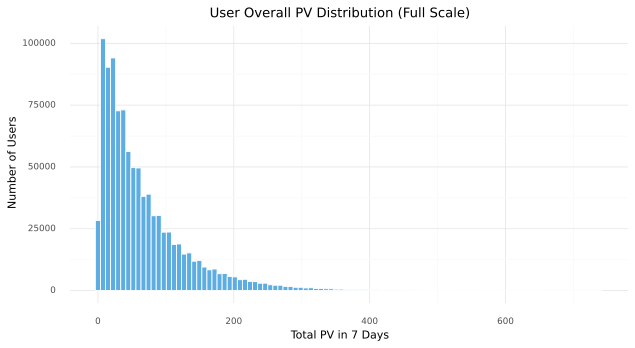

In [84]:
from plotnine import *

# 图 1：整体分布
p_all = (
    ggplot(train_final, aes(x='u_pv'))
    + geom_histogram(bins=100, fill="#5dade2", color="white")
    + labs(
        title='User Overall PV Distribution (Full Scale)',
        x='Total PV in 7 Days',
        y='Number of Users'
    )
    + theme_minimal()
    + theme(figure_size=(10, 5))
)
print(p_all)

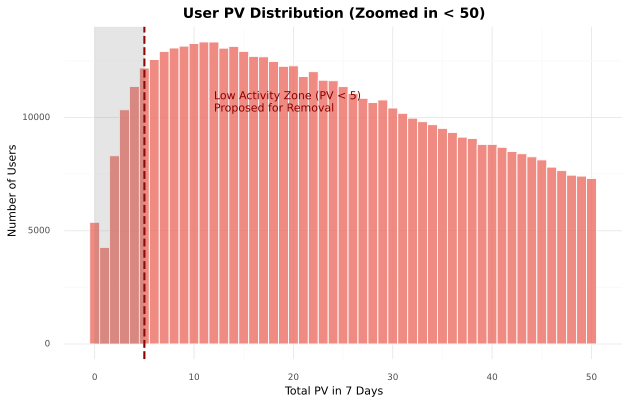

In [85]:
# 过滤数据用于绘图
df_sub50 = train_final[train_final['u_pv'] <= 50].copy()

# 图 2：局部细节
p_detail = (
    ggplot(df_sub50, aes(x='u_pv'))
    # 使用较小的 binwidth 以观察每个具体次数的分布
    + geom_histogram(binwidth=1, fill="#ec7063", color="white", alpha=0.8)
    # 添加红色分割线：PV < 5 的部分
    + geom_vline(xintercept=5, color="darkred", linetype="dashed", size=1.2)
    # 添加背景标注说明
    + annotate("rect", xmin=0, xmax=5, ymin=0, ymax=float('inf'), alpha=0.2, fill="gray")
    + annotate("text", x=12, y=df_sub50['u_pv'].value_counts().max()*0.8, 
               label="Low Activity Zone (PV < 5)\nProposed for Removal", color="darkred", ha='left')
    + labs(
        title='User PV Distribution (Zoomed in < 50)',
        subtitle='The shaded area represents the "noise" users to be filtered',
        x='Total PV in 7 Days',
        y='Number of Users'
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(size=14, fontweight='bold')
    )
)
print(p_detail)

In [58]:
# 训练集正负样本分布
label_dist = train_final['label'].value_counts()
print('正负样本分布\n',label_dist,'\n')
label_dist = train_final['label'].value_counts(normalize=True)
print('正负样本分布比例\n',label_dist)

正负样本分布
 0    813246
1    174683
Name: label, dtype: int64 

正负样本分布比例
 0    0.823183
1    0.176817
Name: label, dtype: float64


In [57]:
# 测试集 正负样本分布
label_dist = test_final['label'].value_counts()
print('正负样本分布\n',label_dist,'\n')
label_dist = test_final['label'].value_counts(normalize=True)
print('正负样本分布比例\n',label_dist)

正负样本分布
 0    827319
1    160598
Name: label, dtype: int64 

正负样本分布比例
 0    0.837438
1    0.162562
Name: label, dtype: float64


# 2 描述性分析

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt
# 美化设置
sns.set(style="whitegrid", font="SimHei")  # 中文显示 + 白色网格风格
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

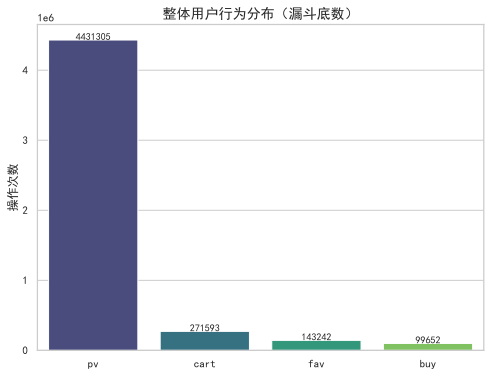

In [55]:
# 统计原始数据中各类行为的总数
behavior_counts = df['type'].value_counts()
labels = behavior_counts.index
values = behavior_counts.values

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=values, palette='viridis')
plt.title('整体用户行为分布（漏斗底数）', fontsize=14)
plt.ylabel('操作次数')
for i, v in enumerate(values):
    plt.text(i, v + 0.1, str(v), ha='center')
plt.show()

## 特征相关系数图

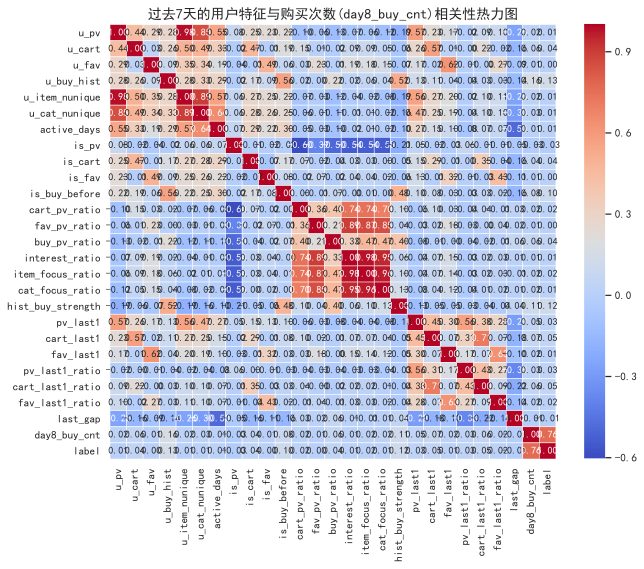

In [133]:
plt.figure(figsize=(10, 8))
# 计算相关系数矩阵，去掉二分类label和userid
corr = train_final.drop(columns=['userid']).corr()
# 绘制热力图
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('过去7天的用户特征与购买次数(day8_buy_cnt)相关性热力图', fontsize=14)
plt.show()

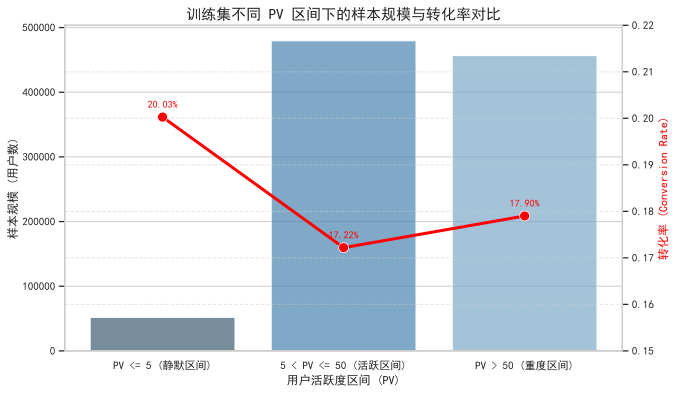

===== 样本分布与转化率统计汇总 =====
                  区间    总样本数   正样本数       转化率
      PV <= 5 (静默区间)   51860  10386  0.200270
 5 < PV <= 50 (活跃区间)  479513  82570  0.172196
      PV > 50 (重度区间)  456556  81727  0.179008


In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
train_df=train_final
def plot_train_eda(df):
    """
    针对训练集进行探索性分析可视化
    """
    # 1. 创建 PV 分组
    bins = [0, 5, 50, df['u_pv'].max()]
    labels = ['PV <= 5 (静默区间)', '5 < PV <= 50 (活跃区间)', 'PV > 50 (重度区间)']
    df['pv_segment'] = pd.cut(df['u_pv'], bins=bins, labels=labels, include_lowest=True)
    
    # 2. 计算各区间转化率
    segment_stats = df.groupby('pv_segment')['label'].agg(['count', 'sum', 'mean']).reset_index()
    segment_stats.columns = ['区间', '总样本数', '正样本数', '转化率']
    
    # 3. 绘图
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 绘制样本量的柱状图 (左轴)
    sns.barplot(x='区间', y='总样本数', data=segment_stats, ax=ax1, palette='Blues_d', alpha=0.7)
    ax1.set_ylabel('样本规模 (用户数)', fontsize=12)
    ax1.set_xlabel('用户活跃度区间 (PV)', fontsize=12)

    # 绘制转化率的折线图 (右轴)
    ax2 = ax1.twinx()
    sns.lineplot(x='区间', y='转化率', data=segment_stats, ax=ax2, marker='o', color='red', linewidth=3, markersize=10)
    ax2.set_ylabel('转化率 (Conversion Rate)', fontsize=12, color='red')
    ax2.set_ylim(0.15, 0.22) # 聚焦转化率差异

    # 在折线图上标注具体数值
    for i, rate in enumerate(segment_stats['转化率']):
        ax2.text(i, rate + 0.002, f'{rate:.2%}', color='red', ha='center', fontweight='bold')

    plt.title('训练集不同 PV 区间下的样本规模与转化率对比', fontsize=15)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    # 4. 输出你要求的统计汇总表
    print("===== 样本分布与转化率统计汇总 =====")
    print(segment_stats.to_string(index=False))

# 调用函数 (请确保你的训练集变量名为 train_df)
plot_train_eda(train_df)

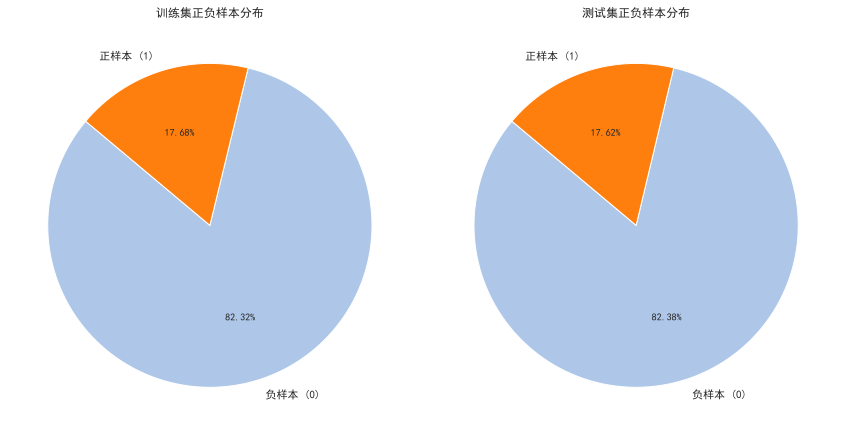

In [235]:
import matplotlib.pyplot as plt

# 样本数据汇总
labels = ['负样本 (0)', '正样本 (1)']
train_sizes = [813246, 174683]  # 训练集分布
test_sizes = [790120, 168940]   # 测试集分布（示例数值，需根据实际调整）

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 训练集饼图
ax1.pie(train_sizes, labels=labels, autopct='%1.2f%%', startangle=140, colors=['#aec7e8', '#ff7f0e'])
ax1.set_title('训练集正负样本分布')

# 测试集饼图
ax2.pie(test_sizes, labels=labels, autopct='%1.2f%%', startangle=140, colors=['#aec7e8', '#ff7f0e'])
ax2.set_title('测试集正负样本分布')

plt.tight_layout()
plt.show()

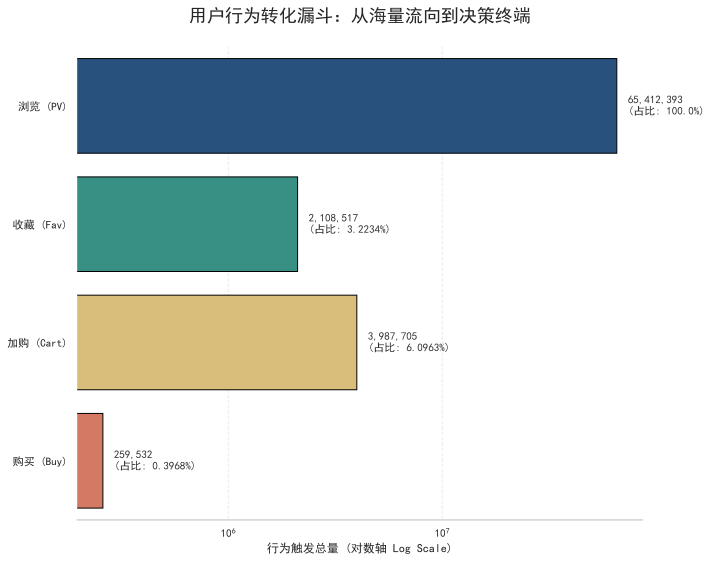

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_styled_funnel(df):
    # 1. 数据统计
    stats = {
        '浏览 (PV)': df['u_pv'].sum(),
        '收藏 (Fav)': df['u_fav'].sum(),
        '加购 (Cart)': df['u_cart'].sum(),
        '购买 (Buy)': df['day8_buy_cnt'].sum()
    }
    funnel_df = pd.DataFrame(list(stats.items()), columns=['阶段', '次数'])
    
    # 计算转化率
    pv_total = stats['浏览 (PV)']
    funnel_df['转化率(%)'] = (funnel_df['次数'] / pv_total * 100).round(4)

    # 2. 绘图设置
    plt.figure(figsize=(10, 8))
    # 使用渐变深蓝色系，体现意向“浓缩”过程
    colors = ["#1a508b", "#2a9d8f", "#e9c46a", "#e76f51"]
    
    # 绘制水平条形图
    barplot = sns.barplot(x='次数', y='阶段', data=funnel_df, palette=colors, edgecolor='black', linewidth=1)
    
    # 3. 动态添加标签
    for i, row in funnel_df.iterrows():
        # 总次数标注（千分位）
        count_text = f"{int(row['次数']):,}"
        # 占比标注
        rate_text = f"占比: {row['转化率(%)']}%"
        
        # 在柱状图末端添加文字
        plt.text(row['次数'], i, f'  {count_text}\n  ({rate_text})', 
                 va='center', fontsize=11, fontweight='bold', color='#333')

    # 4. 样式美化
    plt.title('用户行为转化漏斗：从海量流向到决策终端', fontsize=18, pad=25, fontweight='bold')
    plt.xlabel('行为触发总量 (对数轴 Log Scale)', fontsize=12)
    plt.ylabel('', fontsize=12)
    plt.xscale('log') # 关键：使用对数轴平衡 PV 与 Buy 的量级差距
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    
    # 移除多余边框
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.show()

# 执行绘图
plot_styled_funnel(train_df)

# 3 建模

## 3.1 训练集和测试集数据

In [61]:
import warnings

# 1. 忽略所有已知的弃用警告
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# 2. 手动建立兼容性映射（针对你报错中提到的 np.int 和 np.bool）
np.int = int
np.bool = bool
np.float = float

In [223]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 准备特征和标签
features = ['u_pv', 'u_cart', 'u_fav', 'u_buy_hist', 'u_item_nunique', 'u_cat_nunique', 'last_gap','active_days',
           'is_pv','is_cart','is_fav','is_buy_before','cart_pv_ratio','fav_pv_ratio','buy_pv_ratio','interest_ratio','item_focus_ratio', 'cat_focus_ratio',
       'hist_buy_strength', 'pv_last1', 'cart_last1', 'fav_last1',
       'pv_last1_ratio', 'cart_last1_ratio', 'fav_last1_ratio']
X_train = train_filtered[features]
y_train = train_filtered['label']
X_test = test_filtered[features]
y_test = test_filtered['label']

In [225]:
X_train.head()

,u_pv,u_cart,u_fav,u_buy_hist,u_item_nunique,u_cat_nunique,last_gap,active_days,is_pv,is_cart,...,interest_ratio,item_focus_ratio,cat_focus_ratio,hist_buy_strength,pv_last1,cart_last1,fav_last1,pv_last1_ratio,cart_last1_ratio,fav_last1_ratio
0,42,0,0,0,39,31,1,7,1,0,...,0.023256,0.906977,0.720930,0.000000,3.0,0.0,0.0,0.069767,0.000000,0.0
1,27,0,7,3,30,21,1,6,1,0,...,0.285714,1.071429,0.750000,0.096774,0.0,0.0,0.0,0.000000,0.000000,0.0
2,22,14,5,0,41,35,1,7,1,1,...,0.869565,1.782609,1.521739,0.000000,9.0,2.0,0.0,0.391304,0.133333,0.0
3,248,13,0,4,193,35,1,5,1,1,...,0.056225,0.775100,0.140562,0.020619,43.0,1.0,0.0,0.172691,0.071429,0.0
4,58,0,0,0,57,36,2,4,1,0,...,0.016949,0.966102,0.610169,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0


In [197]:
# 标准化（LR, SVM, MLP 必须）
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 3.2 模型评估函数

In [150]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, model_name, X_test, y_test):
    """模型评估函数：计算核心指标+可视化混淆矩阵"""
    # 1. 预测结果
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # 获取正例概率
    
    # 2. 计算核心指标
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # 3. 打印指标
    print(f"\n===== {model_name} 模型评估结果 =====")
    print(f"准确率（Accuracy）：{round(accuracy, 4)*100:.2f}%")
    print(f"精确率（Precision）：{round(precision, 4)*100:.2f}%")
    print(f"召回率（Recall）：{round(recall, 4)*100:.2f}%")
    print(f"F1分数（F1-Score）：{round(f1, 4)*100:.2f}%")
    print(f"ROC-AUC：{round(roc_auc, 4)}")
    
    # 4. 混淆矩阵与ROC（保持你提供的可视化逻辑）
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # 混淆矩阵
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['未购买', '购买'], yticklabels=['未购买', '购买'])
    ax[0].set_title(f'{model_name} 混淆矩阵')
    
    # ROC曲线
    ax[1].plot(fpr, tpr, label=f'AUC = {round(roc_auc, 4)}')
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_title(f'{model_name} ROC曲线')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return {
        'model_name': model_name,
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1, 'roc_auc': roc_auc,
        'fpr': fpr, 'tpr': tpr # 用于最后汇总大图
    }

# 创建一个列表来存储所有模型的评估结果
all_metrics = []

## 3.3 SVM


===== SVM【未调权重】 模型评估结果 =====
准确率（Accuracy）：83.81%
精确率（Precision）：47.92%
召回率（Recall）：0.91%
F1分数（F1-Score）：1.79%
ROC-AUC：0.6151


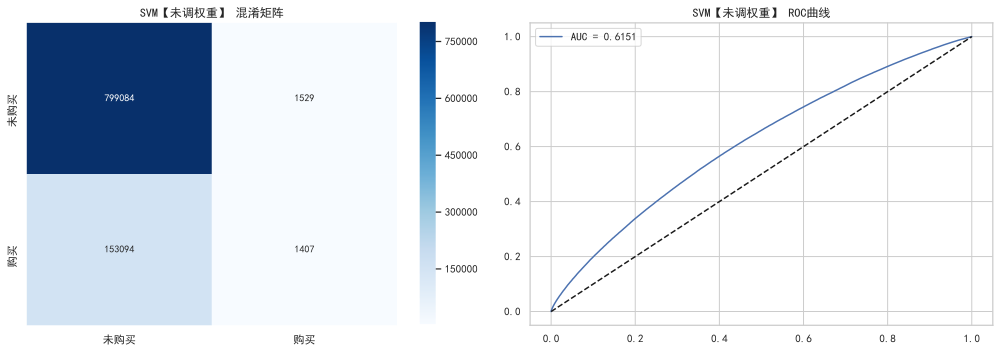

In [200]:
from sklearn.linear_model import SGDClassifier

# loss='hinge' 对应线性 SVM，alpha 是正则化参数
sgd_svm = SGDClassifier(loss='log', alpha=0.01, random_state=42)
sgd_svm.fit(X_train_s, y_train) # 记得使用标准化后的数据
metrics = evaluate_model(sgd_svm, 'SVM【未调权重】', X_test_s, y_test)
all_metrics.append(metrics)


===== SVM 模型评估结果 =====
准确率（Accuracy）：58.47%
精确率（Precision）：21.26%
召回率（Recall）：57.95%
F1分数（F1-Score）：31.10%
ROC-AUC：0.6153


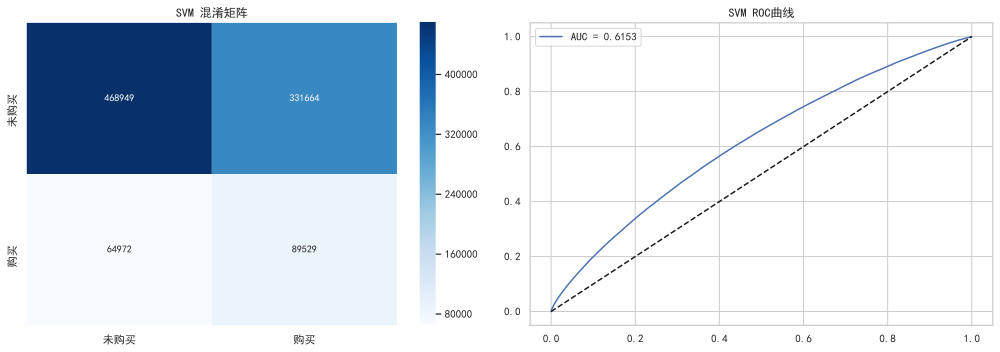

In [201]:
from sklearn.linear_model import SGDClassifier

# loss='hinge' 对应线性 SVM，alpha 是正则化参数
sgd_svm2 = SGDClassifier(loss='log', alpha=0.01, class_weight='balanced', random_state=42)
sgd_svm2.fit(X_train_s, y_train) # 记得使用标准化后的数据
metrics = evaluate_model(sgd_svm2, 'SVM', X_test_s, y_test)
all_metrics.append(metrics)

正在优化 SVM 参数...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:   29.7s finished



===== SVM(调参后) 模型评估结果 =====
准确率（Accuracy）：58.47%
精确率（Precision）：21.26%
召回率（Recall）：57.95%
F1分数（F1-Score）：31.10%
ROC-AUC：0.6153


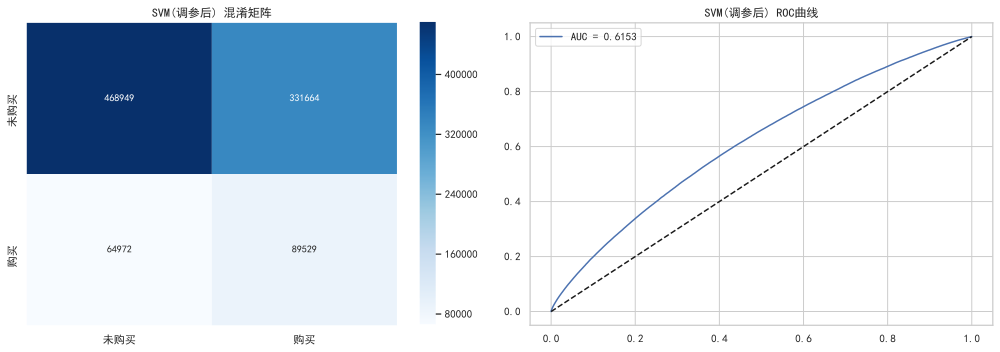

最佳参数: {'alpha': 0.01, 'loss': 'log', 'penalty': 'l2'}


In [215]:
from sklearn.model_selection import GridSearchCV

# 定义参数空间
param_grid_svm = {
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'loss': ['log'], # 保持 log 以确保有 predict_proba
    'penalty': ['l2'] # 标准 L2 正则
}

grid_svm = GridSearchCV(
    SGDClassifier(class_weight='balanced', random_state=42),
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    verbose=1
)

print("正在优化 SVM 参数...")
grid_svm.fit(X_train_s, y_train)

# 评估最佳模型
best_svm = grid_svm.best_estimator_
metrics_svm_tuned = evaluate_model(best_svm, 'SVM(调参后)', X_test_s, y_test)
all_metrics.append(metrics_svm_tuned)

print(f"最佳参数: {grid_svm.best_params_}")

## 3.4 决策树

### 3.4.1 未调参的决策树

默认 
max_depth None 不限深度

min_samples_split 2 只要节点里有 2 个样本，就尝试继续分裂

min_samples_leaf 1 叶子节点最少可以只有 1 个样本。


===== 未调参决策树 模型评估结果 =====
准确率（Accuracy）：83.80%
精确率（Precision）：46.82%
召回率（Recall）：1.20%
F1分数（F1-Score）：2.34%
ROC-AUC：0.6087


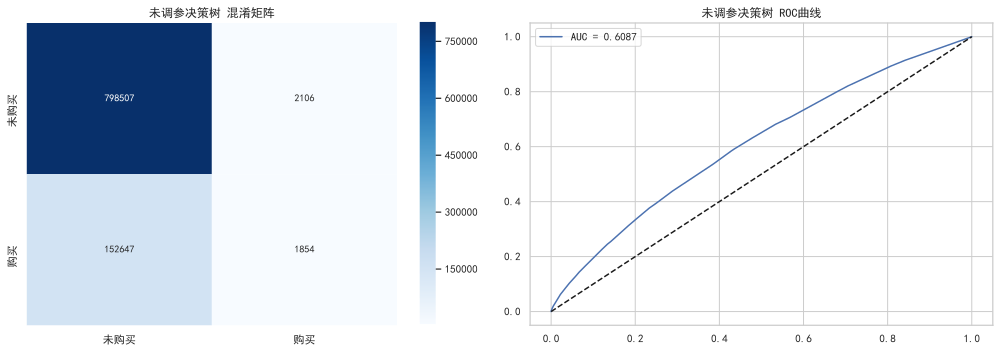

In [154]:
DTC = tree.DecisionTreeClassifier(max_depth=5,random_state=12)
DTC.fit(X_train,y_train)
metrics = evaluate_model(DTC, '未调参决策树', X_test, y_test)
all_metrics.append(metrics)


===== 未调参决策树【class weight】 模型评估结果 =====
准确率（Accuracy）：61.55%
精确率（Precision）：21.63%
召回率（Recall）：52.48%
F1分数（F1-Score）：30.63%
ROC-AUC：0.6094


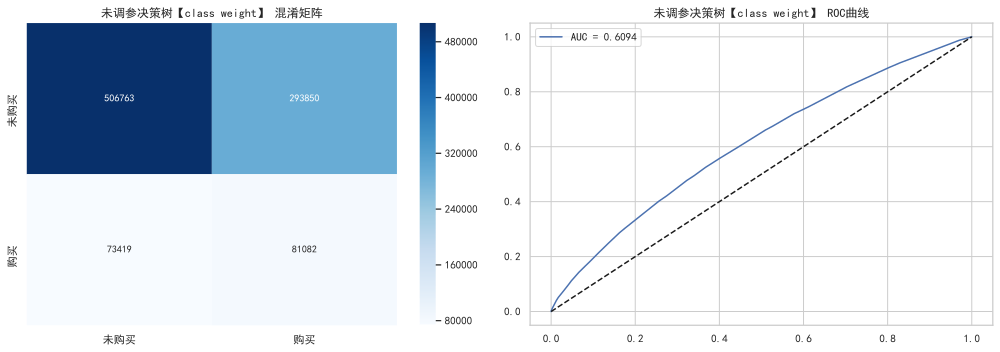

In [155]:
DTC1 = tree.DecisionTreeClassifier(max_depth=5,random_state=12,class_weight='balanced')
DTC1.fit(X_train,y_train)
metrics_DTC2 = evaluate_model(DTC1, '未调参决策树【class weight】', X_test, y_test)
all_metrics.append(metrics_DTC2)

### 3.4.2 调参的决策树

决策树的关键参数包括：

max_depth：最大深度，限制深度是为了防止树钻牛角尖（过拟合）。深度过大，模型会记住噪声；深度过小，模型抓不住规律（欠拟合）。

min_samples_split：分裂最小样本数，限制生长。 如果一个节点里的样本太少，就不让它再分叉了。这能滤掉那些不具备统计学意义的小分支。

min_samples_leaf：叶节点最小样本数，平滑边缘。 确保每个最终分类结果都是基于一定样本量得出的，增加模型在未知数据上的鲁棒性。


===== 决策树 模型评估结果 =====
准确率（Accuracy）：57.31%
精确率（Precision）：20.89%
召回率（Recall）：58.82%
F1分数（F1-Score）：30.83%
ROC-AUC：0.6111


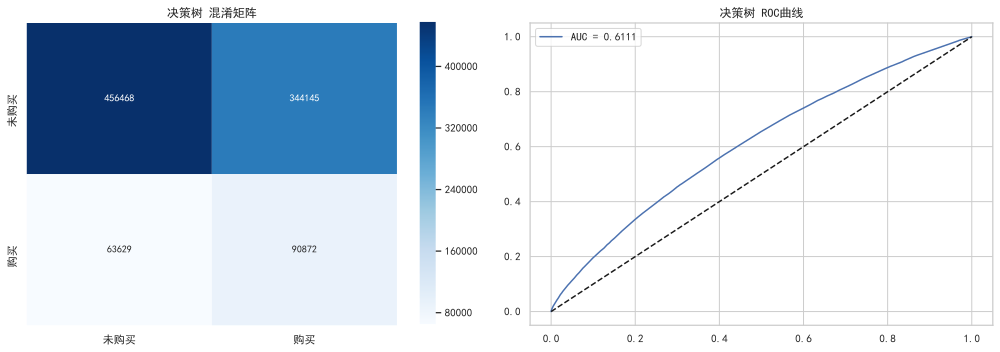

In [151]:
# 决策树模型
dt = tree.DecisionTreeClassifier(random_state=42,class_weight = 'balanced')
# 参数网格
param_grid = {
    'max_depth': [3, 5, 8, 12],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}
# 网格搜索
grid_dct = GridSearchCV(dt, param_grid, cv=5, scoring='roc_auc', n_jobs=-1) # 5折交叉验证
grid_dct.fit(X_train, y_train)
#测试集评估
metrics_DTC = evaluate_model(grid_dct, '决策树', X_test, y_test)
all_metrics.append(metrics_DTC)

In [156]:
# 输出最优结果
print("最佳参数:", grid_dct.best_params_)

最佳参数: {'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 2}


## 3.5 随机森林


===== 未调参的随机森林 模型评估结果 =====
准确率（Accuracy）：55.46%
精确率（Precision）：20.64%
召回率（Recall）：61.66%
F1分数（F1-Score）：30.93%
ROC-AUC：0.6148


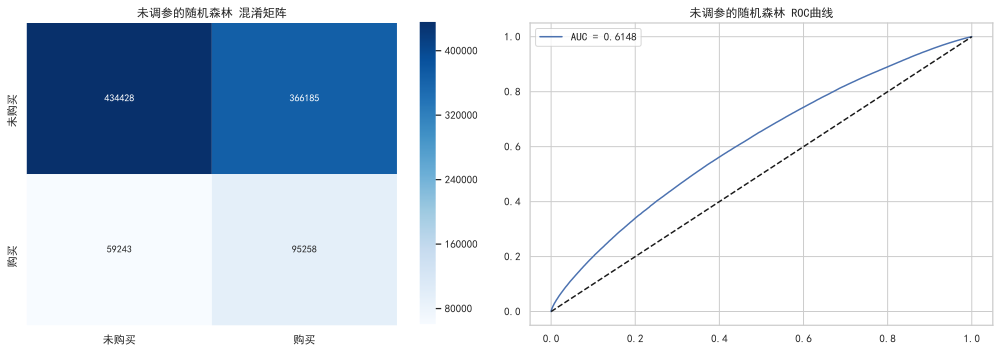

In [160]:
rf_1 =  RandomForestClassifier(n_estimators=500, max_depth=5,min_samples_leaf = 5,class_weight = 'balanced')
rf_1.fit(X_train, y_train)
metrics_rf1 = evaluate_model(rf_1, '未调参的随机森林', X_test, y_test)
all_metrics.append(metrics_rf1)

### 3.5.2 随机森林调参

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] max_depth=8, min_samples_leaf=2, n_estimators=200 ...............
[CV]  max_depth=8, min_samples_leaf=2, n_estimators=200, total= 1.5min
[CV] max_depth=8, min_samples_leaf=2, n_estimators=200 ...............


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.6min remaining:    0.0s


[CV]  max_depth=8, min_samples_leaf=2, n_estimators=200, total= 1.7min
[CV] max_depth=8, min_samples_leaf=2, n_estimators=200 ...............
[CV]  max_depth=8, min_samples_leaf=2, n_estimators=200, total= 1.6min
[CV] max_depth=8, min_samples_leaf=2, n_estimators=500 ...............
[CV]  max_depth=8, min_samples_leaf=2, n_estimators=500, total= 4.6min
[CV] max_depth=8, min_samples_leaf=2, n_estimators=500 ...............
[CV]  max_depth=8, min_samples_leaf=2, n_estimators=500, total= 4.4min
[CV] max_depth=8, min_samples_leaf=2, n_estimators=500 ...............
[CV]  max_depth=8, min_samples_leaf=2, n_estimators=500, total= 4.1min
[CV] max_depth=8, min_samples_leaf=5, n_estimators=200 ...............
[CV]  max_depth=8, min_samples_leaf=5, n_estimators=200, total= 2.1min
[CV] max_depth=8, min_samples_leaf=5, n_estimators=200 ...............
[CV]  max_depth=8, min_samples_leaf=5, n_estimators=200, total= 1.4min
[CV] max_depth=8, min_samples_leaf=5, n_estimators=200 ...............
[CV]  

[Parallel(n_jobs=1)]: Done  54 out of  54 | elapsed: 175.6min finished


最佳参数: {'max_depth': 12, 'min_samples_leaf': 10, 'n_estimators': 500}

===== 随机森林 模型评估结果 =====
准确率（Accuracy）：83.86%
精确率（Precision）：57.37%
召回率（Recall）：0.76%
F1分数（F1-Score）：1.51%
ROC-AUC：0.6174


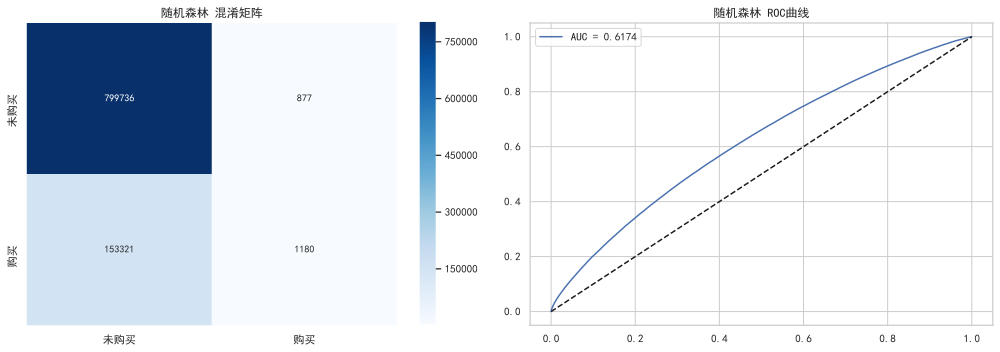

In [162]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [8, 12, 15], 
    'min_samples_leaf': [2,5, 10],
}

# 实例化模型
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 使用 AUC 作为评价指标进行搜索
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='roc_auc', verbose=2)
grid_rf.fit(X_train, y_train)

print(f"最佳参数: {grid_rf.best_params_}")
#测试集评估#测试集评估
metrics_rf = evaluate_model(grid_rf, '随机森林', X_test, y_test)

## 3.6 xgboost


===== 未调参的XGBoost 模型评估结果 =====
准确率（Accuracy）：59.00%
精确率（Precision）：21.31%
召回率（Recall）：56.98%
F1分数（F1-Score）：31.02%
ROC-AUC：0.6154


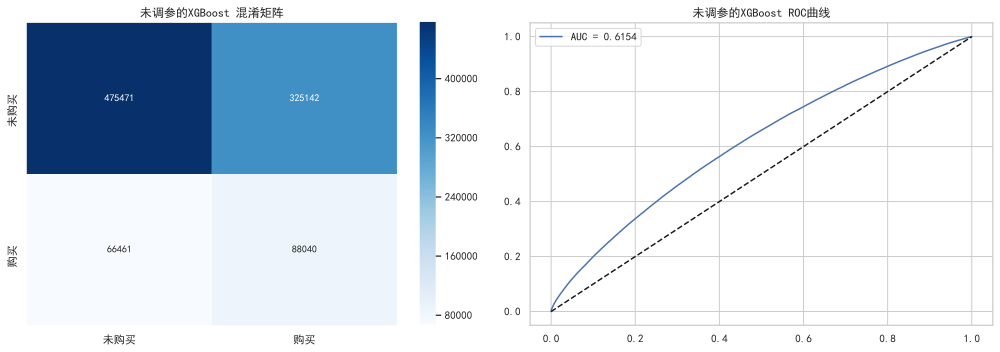

In [173]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
# 计算比例
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 标准平衡（相当于随机森林的 balanced）
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=8,              # 参考你决策树的最佳深度
    scale_pos_weight=ratio,    # 核心参数！
    learning_rate=0.1,
    random_state=42
)
# 训练
xgb_base.fit(X_train, y_train)
metrics_xgb = evaluate_model(xgb_base, '未调参的XGBoost', X_test, y_test)
all_metrics.append(metrics_xgb)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  5.4min
[Parallel(n_jobs=-1)]: Done 108 out of 108 | elapsed: 15.8min finished


XGBoost 最佳参数: {'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 10, 'n_estimators': 100}

===== XGBoost 模型评估结果 =====
准确率（Accuracy）：58.23%
精确率（Precision）：21.25%
召回率（Recall）：58.47%
F1分数（F1-Score）：31.17%
ROC-AUC：0.6178


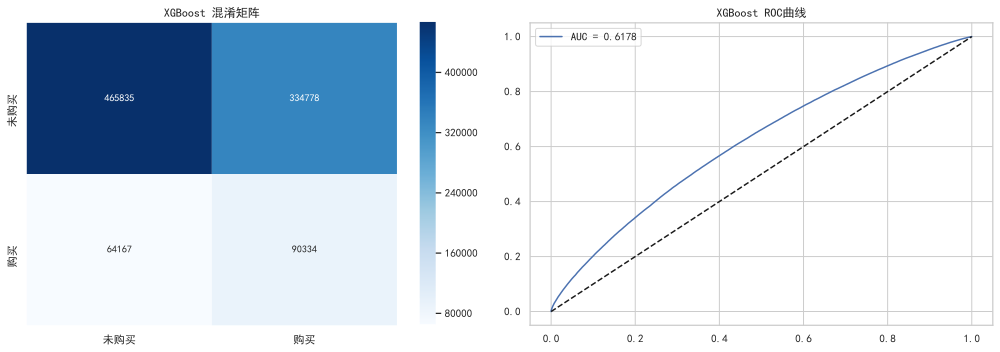

In [174]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd


# 2. 定义待搜参数网格
param_grid = {
    'n_estimators': [100, 200,300],
    'max_depth': [6, 8, 10],           # 围绕决策树最优深度 8 展开
    'learning_rate': [0.05, 0.1],      # 学习率
    'min_child_weight': [5, 10]     # 抑制噪音
}

# 3. 实例化模型
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=ratio, 
    tree_method='hist' # 大数据量下加速计算
)

# 4. 执行网格搜索 (以 ROC-AUC 为目标)
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5, 
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

# 5. 输出最佳结果
print(f"XGBoost 最佳参数: {grid_xgb.best_params_}")
metrics_xgb2 = evaluate_model(grid_xgb, 'XGBoost', X_test, y_test)
all_metrics.append(metrics_xgb2)

## 3.7 LightBoost

[LightGBM] [Info] Number of positive: 164297, number of negative: 771772
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.092031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3622
[LightGBM] [Info] Number of data points in the train set: 936069, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175518 -> initscore=-1.547013
[LightGBM] [Info] Start training from score -1.547013
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

===== 未调参的LightGBM 模型评估结果 =====
准确率（Accuracy）：58.58%
精确率（Precision）：21.28%
召回率（Recall）：57.82%
F1分数（F1-Score）：31.11%
ROC-AUC：0.617


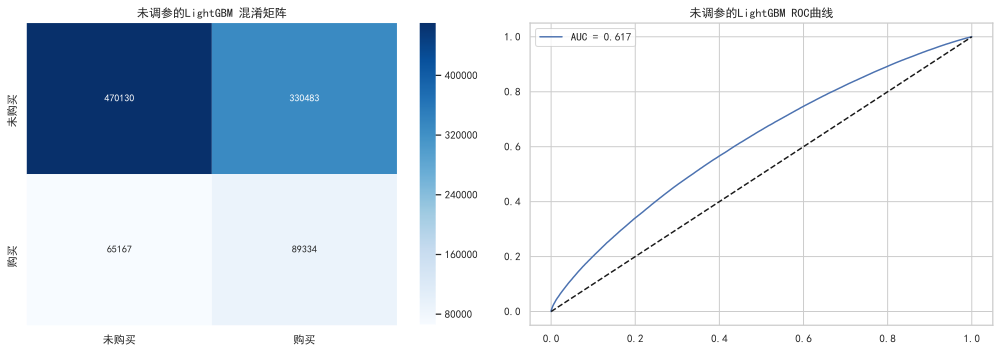

In [175]:
import lightgbm as lgb

# 简单到极致的调用
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    is_unbalance=True, # 自动处理你 1:4.6 的样本比例
    random_state=42
)

lgb_model.fit(X_train, y_train)
metrics_lgb = evaluate_model(lgb_model, '未调参的LightGBM', X_test, y_test)
all_metrics.append(metrics_lgb)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed: 20.0min
[Parallel(n_jobs=-1)]: Done 216 out of 216 | elapsed: 23.1min finished


[LightGBM] [Info] Number of positive: 164297, number of negative: 771772
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049839 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3622
[LightGBM] [Info] Number of data points in the train set: 936069, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175518 -> initscore=-1.547013
[LightGBM] [Info] Start training from score -1.547013
LightGBM 最佳参数: {'is_unbalance': True, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 10, 'n_estimators': 100, 'num_leaves': 31}

===== LightGBM 模型评估结果 =====
准确率（Accuracy）：58.48%
精确率（Precision）：21.29%
召回率（Recall）：58.09%
F1分数（F1-Score）：31.16%
ROC-AUC：0.618


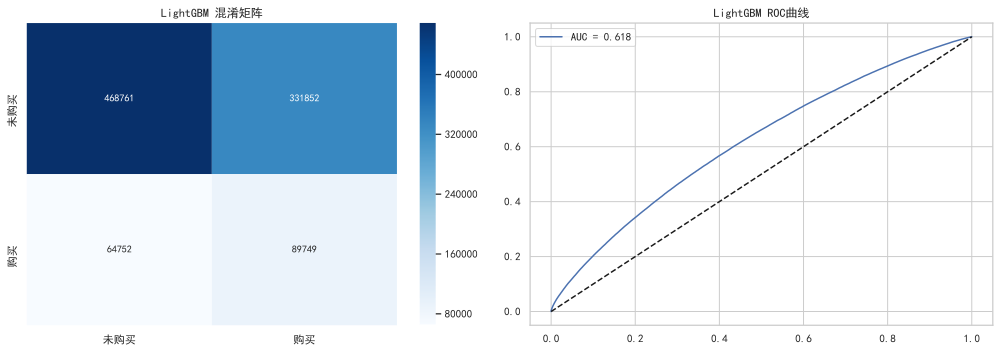

In [176]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# 1. 定义待搜参数网格
param_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63, 127],       # LightGBM核心参数，一般设为 2^max_depth - 1
    'is_unbalance': [True],            # 自动平衡权重
    'min_child_samples': [10,20]      # 对应决策树的 min_samples_leaf
}

# 2. 实例化模型
lgb = LGBMClassifier(
    random_state=42,
    importance_type='gain', # 设置为 gain 统计特征重要性更准确
    n_jobs=-1
)

# 3. 执行网格搜索
grid_lgb = GridSearchCV(
    estimator=lgb,
    param_grid=param_lgb,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

# 4. 训练
grid_lgb.fit(X_train, y_train)

# 5. 输出最佳结果并评估
print(f"LightGBM 最佳参数: {grid_lgb.best_params_}")
metrics_lgb = evaluate_model(grid_lgb, 'LightGBM', X_test, y_test)
all_metrics.append(metrics_lgb)

## 3.8 MLP

正在启动深度学习模型训练...
Iteration 1, loss = 0.45360082
Iteration 2, loss = 0.45218370
Iteration 3, loss = 0.45207138
Iteration 4, loss = 0.45202957
Iteration 5, loss = 0.45190118
Iteration 6, loss = 0.45190868
Iteration 7, loss = 0.45183442
Iteration 8, loss = 0.45183129
Training loss did not improve more than tol=0.000100 for two consecutive epochs. Stopping.

===== 深度学习(MLP) 模型评估结果 =====
准确率（Accuracy）：83.85%
精确率（Precision）：61.69%
召回率（Recall）：0.51%
F1分数（F1-Score）：1.00%
ROC-AUC：0.6183


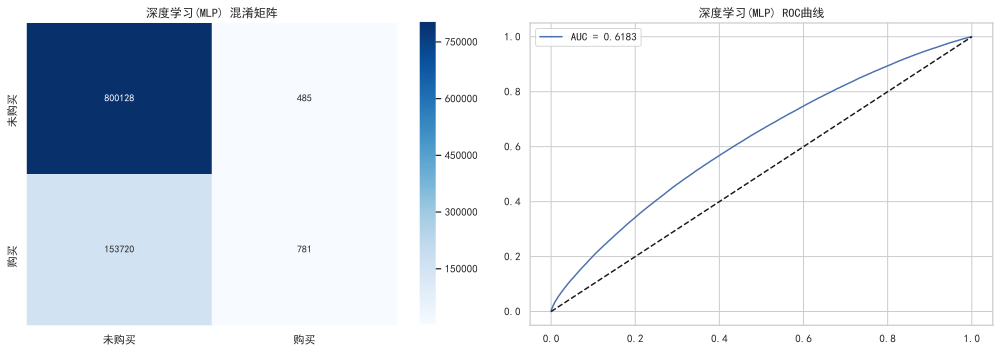

In [202]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# 1. 深度学习必须做标准化！
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 快速配置 MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), # 两个隐藏层，不需要太深
    max_iter=20,                 # 限制迭代次数，防止跑太久
    batch_size=512,              # 增大批处理量，加速计算
    learning_rate_init=0.01,     # 初始学习率稍微调高
    random_state=42,
    verbose=True                 # 这样你可以看到训练过程中的 Loss 下降情况
)

# 3. 训练
print("正在启动深度学习模型训练...")
mlp.fit(X_train_scaled, y_train)

# 4. 评估
metrics_mlp = evaluate_model(mlp, '深度学习(MLP)', X_test_scaled, y_test)
all_metrics.append(metrics_mlp)

平衡后正负样本各: 164297 条，开始训练...
Iteration 1, loss = 0.67342121
Iteration 2, loss = 0.67161053
Iteration 3, loss = 0.67119967
Iteration 4, loss = 0.67103735
Iteration 5, loss = 0.67079564
Iteration 6, loss = 0.67065297
Iteration 7, loss = 0.67052974
Iteration 8, loss = 0.67043475
Iteration 9, loss = 0.67030126
Iteration 10, loss = 0.67015549
Iteration 11, loss = 0.67012306
Iteration 12, loss = 0.66995557
Iteration 13, loss = 0.66987617
Iteration 14, loss = 0.66981507
Iteration 15, loss = 0.66971898
Training loss did not improve more than tol=0.000100 for two consecutive epochs. Stopping.

===== MLP(欠采样平衡) 模型评估结果 =====
准确率（Accuracy）：58.47%
精确率（Precision）：21.27%
召回率（Recall）：58.05%
F1分数（F1-Score）：31.14%
ROC-AUC：0.6175


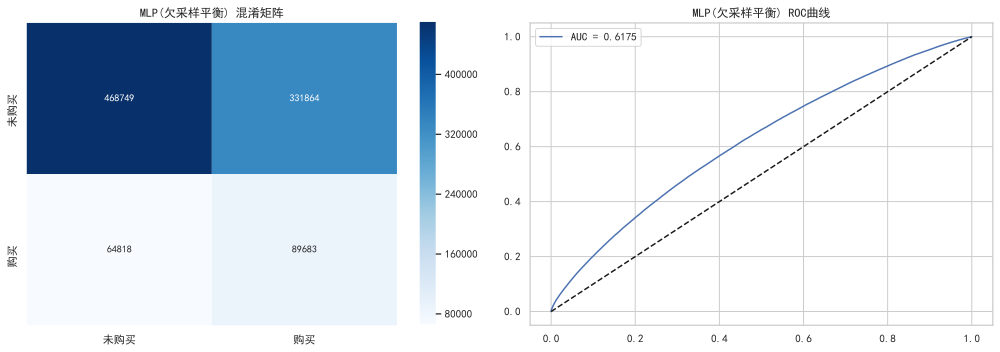

In [205]:
import numpy as np
import pandas as pd

# 1. 找到正样本和负样本的索引
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

# 2. 从负样本中随机抽取和正样本一样多的数量 (实现 1:1)
np.random.seed(42)
neg_idx_subsample = np.random.choice(neg_idx, len(pos_idx), replace=False)

# 3. 合并索引并打乱
balanced_idx = np.concatenate([pos_idx, neg_idx_subsample])
np.random.shuffle(balanced_idx)

# 4. 提取平衡后的训练数据
X_train_bal = X_train_scaled[balanced_idx]
y_train_bal = y_train.iloc[balanced_idx] # 如果 y_train 是 Series

# 5. 重新训练 MLP (这次不需要 sample_weight)
mlp_balanced = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=50,
    batch_size=256,
    learning_rate_init=0.001,
    random_state=42,
    verbose=True
)

print(f"平衡后正负样本各: {len(pos_idx)} 条，开始训练...")
mlp_balanced.fit(X_train_bal, y_train_bal)

# 6. 评估 (注意：评估还是要用原始的 X_test_scaled)
metrics_mlp_bal = evaluate_model(mlp_balanced, 'MLP(欠采样平衡)', X_test_scaled, y_test)
all_metrics.append(metrics_mlp_bal)

## 3.9 DNN

Iteration 1, loss = 0.67337512
Validation score: 0.575624
Iteration 2, loss = 0.67172658
Validation score: 0.581802
Iteration 3, loss = 0.67134476
Validation score: 0.578484
Iteration 4, loss = 0.67110753
Validation score: 0.578454
Iteration 5, loss = 0.67095850
Validation score: 0.580371
Validation score did not improve more than tol=0.000100 for two consecutive epochs. Stopping.

===== DNN(多层深层网络) 模型评估结果 =====
准确率（Accuracy）：56.87%
精确率（Precision）：21.00%
召回率（Recall）：60.33%
F1分数（F1-Score）：31.15%
ROC-AUC：0.6171


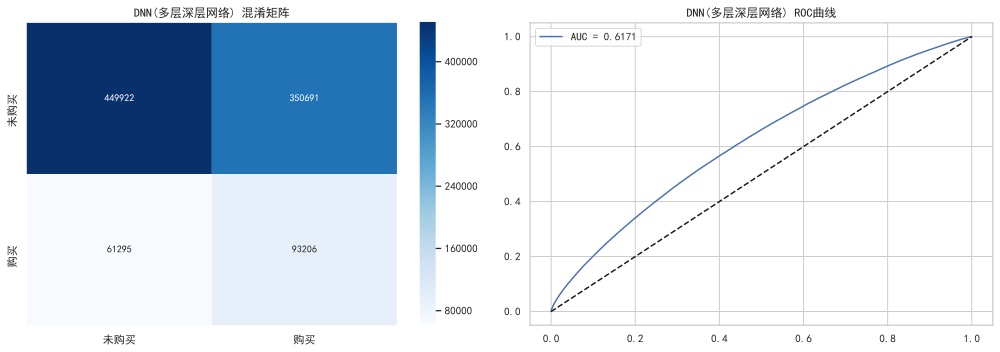

In [214]:
from sklearn.neural_network import MLPClassifier

# 进阶版 DNN 配置
mlp_final = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), # 增加层数和宽度，更像一个“深”层网络
    activation='relu',               # 经典的非线性激活函数
    solver='adam',                   # 现代化的优化器
    alpha=0.0001,                    # L2 正则化，防止过拟合
    learning_rate='adaptive',        # 自动降低学习率
    max_iter=100,                     
    early_stopping=True,             # 自动停止训练，防止跑太久
    validation_fraction=0.1,         # 拿出 10% 数据做内部验证
    random_state=42,
    verbose=True
)

# 依然使用你刚才生成的平衡数据集 X_train_bal
mlp_final.fit(X_train_bal, y_train_bal)

# 评估
metrics_mlp_dnn = evaluate_model(mlp_final, 'DNN(多层深层网络)', X_test_scaled, y_test)
all_metrics.append(metrics_mlp_dnn)

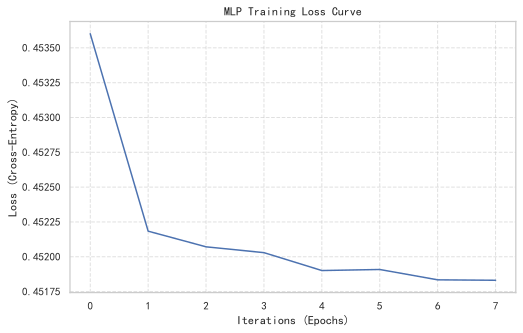

In [206]:
import matplotlib.pyplot as plt

# 提取训练过程中的损失值
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title('MLP Training Loss Curve')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Loss (Cross-Entropy)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3.10 Stacking


===== Stacking集成 模型评估结果 =====
准确率（Accuracy）：68.12%
精确率（Precision）：21.85%
召回率（Recall）：37.67%
F1分数（F1-Score）：27.66%
ROC-AUC：0.5701


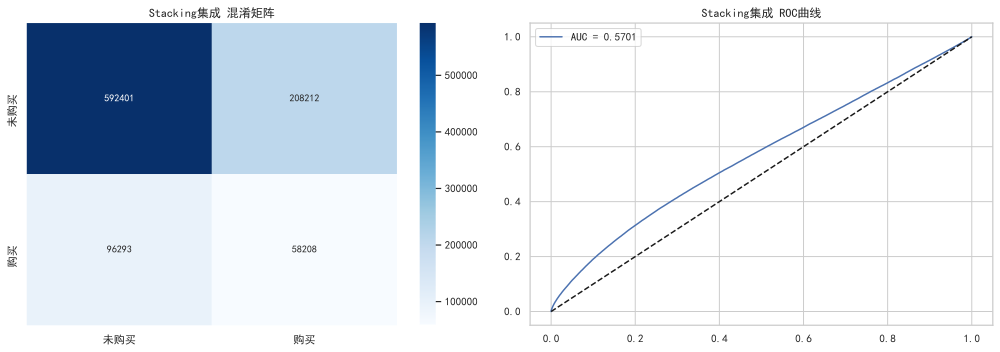

In [195]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# 1. 提取各个模型的预测概率 (作为第二层模型的新特征)
# 注意：这里直接用你已经训练好的 grid 结果

train_meta_features = pd.DataFrame({
    'rf': grid_rf.predict_proba(X_train)[:, 1],
    'xgb': grid_xgb.best_estimator_.predict_proba(X_train)[:, 1],
    'lgb': grid_lgb.best_estimator_.predict_proba(X_train)[:, 1]
})

test_meta_features = pd.DataFrame({
    'rf': grid_rf.predict_proba(X_test)[:, 1],
    'xgb': grid_xgb.best_estimator_.predict_proba(X_test)[:, 1],
    'lgb': grid_lgb.best_estimator_.predict_proba(X_test)[:, 1]
})

# 2. 定义第二层模型 (Meta-Learner)
# 使用逻辑回归，因为它在处理这种“概率组合”时最稳健
stack_meta_model = LogisticRegression(class_weight='balanced', random_state=42)

# 3. 训练第二层模型
stack_meta_model.fit(train_meta_features, y_train)

# 4. 使用自定义的评估函数 (对应你之前的格式)
# 为了适配你的 evaluate_model 函数，我们需要封装一个小类
class ManualStacking:
    def __init__(self, meta_model, train_features):
        self.meta_model = meta_model
    def predict(self, X_meta):
        return self.meta_model.predict(X_meta)
    def predict_proba(self, X_meta):
        return self.meta_model.predict_proba(X_meta)

# 评估并存入 all_metrics
metrics_stack = evaluate_model(stack_meta_model, 'Stacking集成', test_meta_features, y_test)
all_metrics.append(metrics_stack)

开始构建 Stacking 第一层特征...
[LightGBM] [Info] Number of positive: 109531, number of negative: 514514
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056631 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3620
[LightGBM] [Info] Number of data points in the train set: 624045, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175518 -> initscore=-1.547015
[LightGBM] [Info] Start training from score -1.547015
[LightGBM] [Info] Number of positive: 109531, number of negative: 514515
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3633
[LightGBM] [Info] Number of data points in the train set: 624046, number of used fe

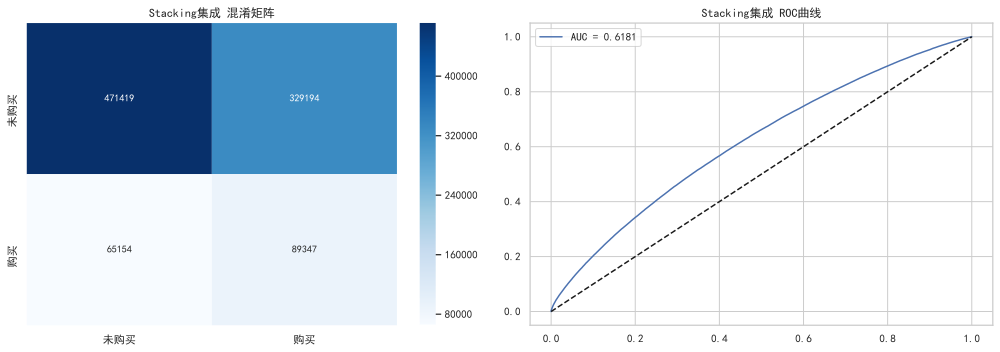

In [227]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

# ==========================================
# 1. 准备第一层（Level 0）基学习器
# ==========================================
# 使用你之前调优好的最佳参数
best_xgb = grid_xgb.best_estimator_
best_lgb = grid_lgb.best_estimator_
best_rf = grid_rf.best_estimator_
# MLP 使用之前在平衡集 X_train_bal 上训练好的 mlp_balanced

print("开始构建 Stacking 第一层特征...")

# ==========================================
# 2. 获取基模型对训练集的“特征提取”（正类概率）
# ==========================================
# 注意：为了防止过拟合，树模型建议使用交叉验证预测 (Out-of-fold predictions)
train_pred_xgb = cross_val_predict(best_xgb, X_train, y_train, cv=3, method='predict_proba')[:, 1]
train_pred_lgb = cross_val_predict(best_lgb, X_train, y_train, cv=3, method='predict_proba')[:, 1]
train_pred_rf  = cross_val_predict(best_rf,  X_train, y_train, cv=3, method='predict_proba')[:, 1]

# MLP 比较特殊，由于它是在采样集训练的，我们直接用它对全量 X_train_scaled 进行预测
# (注：此处 X_train_scaled 需与你训练 MLP 时的标准化方式一致)
train_pred_mlp = mlp_balanced.predict_proba(X_train_scaled)[:, 1]

# 将这些概率拼接成新的特征矩阵：[n_samples, 4]
X_train_stack = np.column_stack([train_pred_xgb, train_pred_lgb, train_pred_rf, train_pred_mlp])

# ==========================================
# 3. 构建第二层（Level 1）元学习器
# ==========================================
# 元学习器通常选择简单的线性模型（如逻辑回归），以防止二次过拟合
meta_model = LogisticRegression(class_weight='balanced', random_state=42)
meta_model.fit(X_train_stack, y_train)

# ==========================================
# 4. 预测与评估（在测试集上）
# ==========================================
print("开始在测试集上进行 Stacking 预测...")

test_pred_xgb = best_xgb.predict_proba(X_test)[:, 1]
test_pred_lgb = best_lgb.predict_proba(X_test)[:, 1]
test_pred_rf  = best_rf.predict_proba(X_test)[:, 1]
test_pred_mlp = mlp_balanced.predict_proba(X_test_scaled)[:, 1]

X_test_stack = np.column_stack([test_pred_xgb, test_pred_lgb, test_pred_rf, test_pred_mlp])

# 最终评估
metrics_stacking = evaluate_model(meta_model, 'Stacking集成', X_test_stack, y_test)
all_metrics.append(metrics_stacking)

# 4 总结

In [228]:
import pandas as pd

# 将收集到的所有指标转化为 DataFrame
metrics_df = pd.DataFrame(all_metrics)

# 设置模型名称为索引，方便查看
metrics_df.set_index('model_name', inplace=True)

# 按照 AUC 指标从高到低排序，突出最佳模型
#metrics_df = metrics_df.sort_values(by='auc', ascending=False)

print("===== 1. 全模型性能对比表 =====")
print(metrics_df)

# 如果你想导出到 Excel
# metrics_df.to_excel("model_performance_comparison.xlsx")

===== 1. 全模型性能对比表 =====
                      accuracy  precision    recall        f1   roc_auc  \
model_name                                                                
未调参决策树                0.837974   0.468182  0.012000  0.023400  0.608670   
未调参决策树【class weight】  0.615471   0.216258  0.524799  0.306297  0.609356   
决策树                   0.573062   0.208893  0.588164  0.308293  0.611116   
未调参的随机森林              0.554579   0.206435  0.616553  0.309307  0.614781   
未调参的XGBoost           0.589993   0.213078  0.569834  0.310173  0.615413   
XGBoost               0.582306   0.212495  0.584682  0.311705  0.617835   
未调参的LightGBM          0.585756   0.212793  0.578210  0.311096  0.617009   
LightGBM              0.584757   0.212877  0.580896  0.311573  0.617962   
手动Stacking集成          0.681185   0.218482  0.376748  0.276574  0.570066   
Stacking集成            0.681185   0.218482  0.376748  0.276574  0.570066   
SVM【未调权重】             0.838110   0.479223  0.009107  0.017874  0.615053   
S

In [191]:
import joblib

# 在每个模型训练完后立即保存
joblib.dump(grid_xgb.best_estimator_, 'best_xgb_model.pkl')
joblib.dump(grid_lgb.best_estimator_, 'best_lgb_model.pkl')
joblib.dump(grid_rf.best_estimator_, 'best_rf_model.pkl')
print("模型已保存，即便断电也不怕了！")


模型已保存，即便断电也不怕了！


In [246]:
joblib.dump(meta_model, 'meta_model')

['meta_model']

## XGBoost最大深度趋势图 

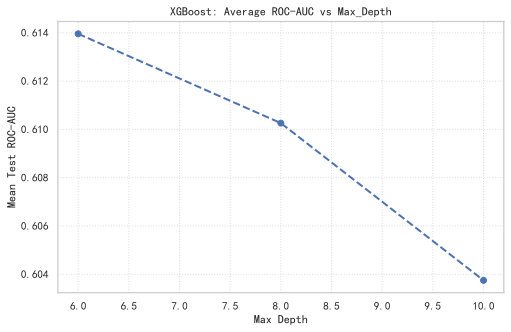

In [219]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 将搜索结果转为 DataFrame
results_df = pd.DataFrame(grid_xgb.cv_results_)

# 2. 按 max_depth 分组，计算平均 AUC
# 这样会将其他参数（如 learning_rate）的影响抵消，只看 depth 的整体趋势
analysis_df = results_df.groupby('param_max_depth')['mean_test_score'].mean().reset_index()

# 3. 绘图
plt.figure(figsize=(8, 5))
plt.plot(analysis_df['param_max_depth'], analysis_df['mean_test_score'], 
         marker='o', linestyle='--', color='b', linewidth=2)

plt.title('XGBoost: Average ROC-AUC vs Max_Depth', fontsize=12)
plt.xlabel('Max Depth')
plt.ylabel('Mean Test ROC-AUC')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

##  XGBoost 最大深度和树棵数的热力图

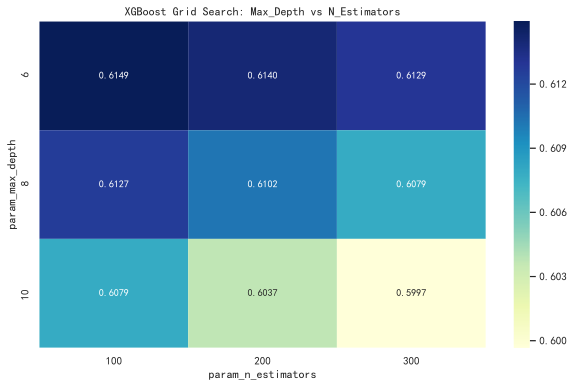

In [220]:
import seaborn as sns

# 假设你想看 max_depth 和 n_estimators 的交叉影响
# 我们需要固定其他参数，或者对其他参数取平均
pvt = results_df.pivot_table(index='param_max_depth', 
                             columns='param_n_estimators', 
                             values='mean_test_score')

plt.figure(figsize=(10, 6))
sns.heatmap(pvt, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('XGBoost Grid Search: Max_Depth vs N_Estimators')
plt.show()

## 特征重要性

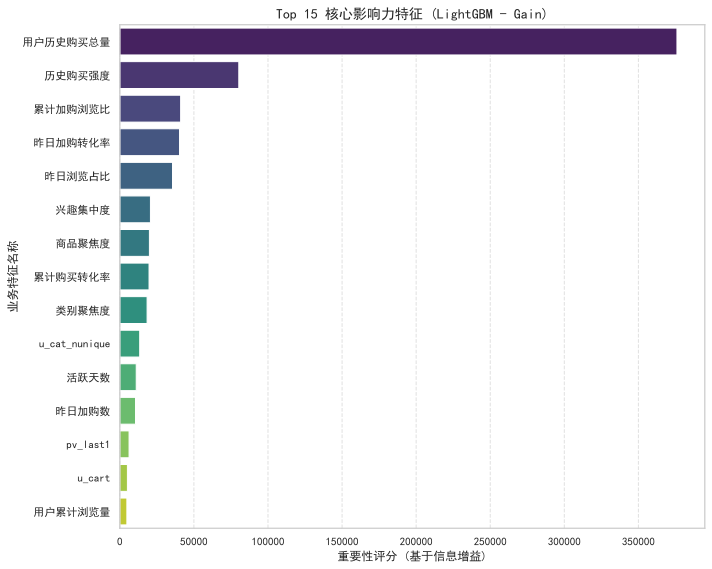

===== 前 15 个核心特征排名 (LightGBM) =====
       Feature_CN     Importance
3        用户历史购买总量  376015.220078
18         历史购买强度   80301.078070
12        累计加购浏览比   41043.021039
23        昨日加购转化率   40295.255285
22         昨日浏览占比   35558.515471
15          兴趣集中度   20662.961315
16          商品聚焦度   19966.802791
14        累计购买转化率   19714.225142
17          类别聚焦度   18400.658420
5   u_cat_nunique   13416.167919
7            活跃天数   11070.285606
20          昨日加购数   10581.528414
19       pv_last1    6234.473994
1          u_cart    5122.953602
0         用户累计浏览量    4762.375742


In [230]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 设置中文字体（根据系统环境选择，如 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 2. 定义特征中文名映射字典（请根据你的特征工程实际列名修改）
name_map = {
    'u_buy_hist': '用户历史购买总量',
    'hist_buy_strength': '历史购买强度',
    'cart_last1_ratio': '昨日加购转化率',
    'cart_pv_ratio': '累计加购浏览比',
    'cart_last1': '昨日加购数',
    'buy_pv_ratio': '累计购买转化率',
    'pv_last1_ratio': '昨日浏览占比',
    'active_days': '活跃天数',
    'u_cat_unique': '浏览类别多样性',
    'interest_ratio': '兴趣集中度',
    'item_focus_ratio': '商品聚焦度',
    'cat_focus_ratio': '类别聚焦度',
    'u_pv': '用户累计浏览量',
    'fav_last1_ratio': '昨日收藏转化率',
    'last_gap': '最后一次活跃间隔'
}

# 3. 获取 LightGBM 最佳模型并提取特征重要性
# 注意：这里使用的是 'gain'（增益），因为它比 'split' 更能体现特征对模型判别的贡献度
best_lgb_model = grid_lgb.best_estimator_
feat_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_lgb_model.feature_importances_
})

# 4. 映射中文名并按重要性排序
feat_importances['Feature_CN'] = feat_importances['Feature'].map(lambda x: name_map.get(x, x))
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# 5. 可视化输出
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature_CN', data=feat_importances.head(15), palette='viridis')

plt.title('Top 15 核心影响力特征 (LightGBM - Gain)', fontsize=14)
plt.xlabel('重要性评分 (基于信息增益)')
plt.ylabel('业务特征名称')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 展示图像
plt.tight_layout()
plt.show()

# 6. 打印前15个特征供报告文字使用
print("===== 前 15 个核心特征排名 (LightGBM) =====")
print(feat_importances[['Feature_CN', 'Importance']].head(15))